# Project for New York TLC



## 🚖 Domain Understanding: New York City TLC

### 🏛️ Who is the TLC?
The **New York City Taxi and Limousine Commission (TLC)** is the government agency that acts as the "referee" for taxi and for-hire transportation in NYC.

Whether it's a famous **Yellow Cab**, a **Green Boro Taxi**, or an app-based ride like **Uber/Lyft**, the TLC regulates it. They are responsible for licensing over **200,000 vehicles** and overseeing approximately **1,000,000 trips every single day**.

---

### 🛠️ What Do They Do?
Their main goal is to ensure safety and fairness. Their key responsibilities include:

* **Licensing:** Every driver must pass background checks, drug tests, and a 24-hour education course to get a "Hack License."
* **Vehicle Safety:** They run strict inspections to ensure cars are road-worthy and meters are accurate.
* **Fare Regulation:** They set the prices for yellow/green cabs and enforce minimum pay standards for app-based drivers.
* **Data Collection:** They record details of every trip (pickup location, dropoff location, distance, and fare).




## Problem Statement

Develop a regression model that helps estimate taxi fares before the ride, based on data that TLC has gathered.



## 🕵️‍♂️ Business Application: Overcharge Detection

### 💡 The Idea
A high-accuracy Fare Prediction model isn't just for estimation—it is a powerful tool for **Fraud Detection**.

By comparing the **Predicted Fare** (what the ride *should* cost) with the **Actual Fare** (what the driver *actually* charged), we can identify anomalies. If the difference is too high, it might indicate:
1.  **Meter Manipulation:** The driver tampered with the meter.
2.  **Inefficient Route:** The driver took a longer route to increase the fare.
3.  **Data Error:** A glitch in the recording system.



# 📂 Dataset Overview & Data Dictionary

### 🔢 Dataset Dimensions
* **Total Rows:** 22,699 (Each row represents a unique taxi trip)
* **Total Columns:** 18 Features

### 📖 Data Dictionary

| Column Name | Description | Key Codes / Notes |
| :--- | :--- | :--- |
| **ID** | Trip identification number | Unique ID for the row. |
| **VendorID** | Code indicating the TPEP provider that provided the record. | **1** = Creative Mobile Technologies<br>**2** = VeriFone Inc. |
| **tpep_pickup_datetime** | The date and time when the meter was engaged. | Start of the trip. |
| **tpep_dropoff_datetime** | The date and time when the meter was disengaged. | End of the trip. |
| **Passenger_count** | The number of passengers in the vehicle. | **Note:** This is a driver-entered value. |
| **Trip_distance** | The elapsed trip distance in miles reported by the taximeter. | |
| **PULocationID** | TLC Taxi Zone in which the taximeter was engaged. | Requires lookup table for zone names. |
| **DOLocationID** | TLC Taxi Zone in which the taximeter was disengaged. | Requires lookup table for zone names. |
| **RateCodeID** | The final rate code in effect at the end of the trip. | **1** = Standard rate<br>**2** = JFK<br>**3** = Newark<br>**4** = Nassau/Westchester<br>**5** = Negotiated fare<br>**6** = Group ride |
| **Store_and_fwd_flag** | Indicates if the record was held in vehicle memory before sending to server. | **Y** = Store and forward trip<br>**N** = Not a store and forward trip |
| **Payment_type** | A numeric code signifying how the passenger paid. | **1** = Credit card<br>**2** = Cash<br>**3** = No charge<br>**4** = Dispute<br>**5** = Unknown<br>**6** = Voided trip |
| **Fare_amount** | The time-and-distance fare calculated by the meter. | Base fare only. |
| **Extra** | Miscellaneous extras and surcharges. | Includes $0.50 and $1 rush hour/overnight charges. |
| **MTA_tax** | $0.50 MTA tax that is automatically triggered based on the metered rate. | |
| **Improvement_surcharge** | $0.30 improvement surcharge assessed at flag drop. | Levied since 2015. |
| **Tip_amount** | Tip amount (automatically populated for credit cards). | **Important:** Cash tips are NOT included. |
| **Tolls_amount** | Total amount of all tolls paid in trip. | |
| **Total_amount** | The total amount charged to passengers. | **Note:** Does not include cash tips. |

---

### ⚠️ Important Data Notes
1.  **Cash Tips:** The `Tip_amount` and `Total_amount` fields do not track cash tips. We should be careful when calculating total revenue or driver income.
2.  **User Input Error:** `Passenger_count` is manually entered by the driver and may contain errors (e.g., 0 passengers or huge numbers).
3.  **Location IDs:** `PULocationID` and `DOLocationID` are numeric IDs. We will need the **Taxi Zone Lookup Table** to map these to real neighborhood names (e.g., Manhattan, Queens).

## Importing Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Data Exploration and Cleaning


In [4]:
df_tlc = pd.read_csv(r"C:\Users\Mohit Yadav\Downloads\tlc.csv")

df_tlc.head(10)



,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80
5,23345809,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36
6,37660487,2,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,1,12.83,1,N,79,241,1,47.5,1.0,0.5,9.86,0.0,0.3,59.16
7,69059411,2,08/15/2017 5:41:06 PM,08/15/2017 6:03:05 PM,1,2.98,1,N,237,114,1,16.0,1.0,0.5,1.78,0.0,0.3,19.58
8,8433159,2,02/04/2017 4:17:07 PM,02/04/2017 4:29:14 PM,1,1.20,1,N,234,249,2,9.0,0.0,0.5,0.00,0.0,0.3,9.80
9,95294817,1,11/10/2017 3:20:29 PM,11/10/2017 3:40:55 PM,1,1.60,1,N,239,237,1,13.0,0.0,0.5,2.75,0.0,0.3,16.55


In [5]:
df_tlc.rename(columns={'Unnamed: 0':'id'}, inplace=True)

#First Column is Trip Identification number

In [6]:
df_tlc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

Findings :

* tpep_pickup_datetime, tpep_dropoff_datetime should be in datetime
* Data Type of VendorID, RatecodeID, PULocationID, DOLocationID, payment_type should be str



In [7]:
df_tlc['tpep_pickup_datetime'] = pd.to_datetime(df_tlc['tpep_pickup_datetime'])
df_tlc['tpep_dropoff_datetime'] = pd.to_datetime(df_tlc['tpep_dropoff_datetime'])

cat_cols = ["VendorID", "RatecodeID","PULocationID","DOLocationID","payment_type"]

for i in cat_cols:

    df_tlc[i] = df_tlc[i].astype("str")


In [8]:
df_tlc.describe(include='all')

,id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699,22699,22699,22699.000000,22699.000000,22699,22699,22699,22699,22699,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
unique,NaN,2,NaN,NaN,NaN,NaN,6,2,152,216,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2,NaN,NaN,NaN,NaN,1,N,237,161,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,12626,NaN,NaN,NaN,NaN,22070,22600,890,858,15265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5.675849e+07,NaN,2017-06-29 07:32:48.973126656,2017-06-29 07:49:49.799726848,1.642319,2.913313,NaN,NaN,NaN,NaN,NaN,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
min,1.212700e+04,NaN,2017-01-01 00:08:25,2017-01-01 00:17:20,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,NaN,2017-03-30 03:09:38.500000,2017-03-30 03:11:20.500000,1.000000,0.990000,NaN,NaN,NaN,NaN,NaN,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,NaN,2017-06-23 12:35:57,2017-06-23 12:55:11,1.000000,1.610000,NaN,NaN,NaN,NaN,NaN,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,NaN,2017-10-02 10:34:34,2017-10-02 10:53:47,2.000000,3.060000,NaN,NaN,NaN,NaN,NaN,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,NaN,2017-12-31 23:45:30,2017-12-31 23:49:24,6.000000,33.960000,NaN,NaN,NaN,NaN,NaN,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


Findings:
  * Min(-120) and MAX(999) are suspicious because Q1, Q2 and Q3 are 6.5, 9.5, 14.5 respectively.
  * Min and Max Trip distance is 0, 33 we need to inspect this as well because 0 trip distance does not make sense
    max is too high compared to its other quartiles.
  * It's a 1 year trips data.





In [9]:
df_tlc.loc[df_tlc["fare_amount"] <0]

,id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
314,105454287,2,2017-12-13 02:02:39,2017-12-13 02:03:08,6,0.12,1,N,161,161,3,-2.5,-0.5,-0.5,0.0,0.0,-0.3,-3.8
1646,57337183,2,2017-07-05 11:02:23,2017-07-05 11:03:00,1,0.04,1,N,79,79,3,-2.5,0.0,-0.5,0.0,0.0,-0.3,-3.3
4423,97329905,2,2017-11-16 20:13:30,2017-11-16 20:14:50,2,0.06,1,N,237,237,4,-3.0,-0.5,-0.5,0.0,0.0,-0.3,-4.3
5448,28459983,2,2017-04-06 12:50:26,2017-04-06 12:52:39,1,0.25,1,N,90,68,3,-3.5,0.0,-0.5,0.0,0.0,-0.3,-4.3
5758,833948,2,2017-01-03 20:15:23,2017-01-03 20:15:39,1,0.02,1,N,170,170,3,-2.5,-0.5,-0.5,0.0,0.0,-0.3,-3.8
8204,91187947,2,2017-10-28 20:39:36,2017-10-28 20:41:59,1,0.41,1,N,236,237,3,-3.5,-0.5,-0.5,0.0,0.0,-0.3,-4.8
10281,55302347,2,2017-06-05 17:34:25,2017-06-05 17:36:29,2,0.00,1,N,238,238,4,-2.5,-1.0,-0.5,0.0,0.0,-0.3,-4.3
11204,58395501,2,2017-07-09 07:20:59,2017-07-09 07:23:50,1,0.64,1,N,50,48,3,-4.5,0.0,-0.5,0.0,0.0,-0.3,-5.3
12944,29059760,2,2017-04-08 00:00:16,2017-04-08 23:15:57,1,0.17,5,N,138,138,4,-120.0,0.0,0.0,0.0,0.0,-0.3,-120.3
14714,109276092,2,2017-12-24 22:37:58,2017-12-24 22:41:08,5,0.40,1,N,164,161,4,-4.0,-0.5,-0.5,0.0,0.0,-0.3,-5.3


**Findings**

Most records with negative `fare_amount` correspond to:

- **RateCodeID = 1** (standard meter)
- **payment_type = 3** (No charge) or **4** (Dispute)

These entries represent fare reversals, refunds, or disputed payments rather than actual meter-calculated fares.



**Assumptions**

Although the trip may have occurred, the recorded fare does **not** reflect the true cost of the ride.
Such records break the expected relationship between trip features (distance, time) and the target variable (`fare_amount`).


**Action**

All rides with:

- negative `fare_amount`
- no-charge or disputed `payment_type`

were removed from the dataset.

These records introduce **label noise** and would mislead the fare prediction model, as the target value does not represent a valid, chargeable ride.


In [10]:
df_tlc = df_tlc.loc[~(df_tlc["fare_amount"] <=0)]

In [11]:
df_tlc = df_tlc[~(df_tlc["payment_type"].isin(["3","4"]))]

In [12]:
df_tlc.isnull().sum()

#There is no null value in the dataset

id                       0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

In [13]:
df_tlc[(df_tlc["trip_distance"] == 0)]

,id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
128,52987734,1,2017-06-22 08:05:33,2017-06-22 08:05:40,1,0.0,3,N,231,231,2,20.0,0.0,0.0,0.00,0.0,0.3,20.30
246,78660848,1,2017-09-18 20:50:53,2017-09-18 20:51:03,1,0.0,1,N,145,145,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80
291,83480088,1,2017-10-04 19:46:24,2017-10-04 19:46:50,1,0.0,1,N,132,132,2,2.5,1.0,0.5,0.00,0.0,0.3,4.30
424,3767951,1,2017-01-14 07:00:26,2017-01-14 07:00:53,1,0.0,1,N,208,208,1,2.5,0.0,0.5,6.70,0.0,0.3,10.00
470,103583013,2,2017-12-07 14:39:18,2017-12-07 14:39:23,1,0.0,5,N,138,138,1,34.0,0.0,0.5,6.96,0.0,0.3,41.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21836,65082578,2,2017-08-01 09:52:15,2017-08-01 09:52:15,3,0.0,5,N,264,143,1,59.0,0.0,0.0,9.00,0.0,0.0,68.00
21977,67022415,1,2017-08-08 07:28:47,2017-08-08 07:28:47,2,0.0,1,N,75,264,2,10.5,0.0,0.5,0.00,0.0,0.3,11.30
22026,63642923,1,2017-07-27 07:44:24,2017-07-27 07:44:24,1,0.0,1,N,41,264,2,10.5,0.0,0.5,0.00,0.0,0.3,11.30
22325,62192517,2,2017-07-21 23:30:29,2017-07-21 23:31:12,1,0.0,5,N,163,163,1,16.8,0.0,0.0,3.42,0.0,0.3,20.52


**Findings**

There are **122 records** with zero trip distance.
This can occur when a ride is booked but not completed (e.g., early cancellation), where only a basic minimum charge is applied.


**Cleaning Rule**

If:
- `trip_distance == 0`
- `trip_duration < 1 minute`
- `fare_amount >= 5`

then the record is **dropped**, as such rides are considered **physically implausible** and represent noisy or corrupted data.

This threshold allows valid short cancellations with minimal charges to be retained while removing extreme inconsistencies.





In [14]:
df_tlc["ride_duration"] = (df_tlc["tpep_dropoff_datetime"] - df_tlc["tpep_pickup_datetime"]).dt.total_seconds()

In [15]:
df_tlc = df_tlc[~((df_tlc["ride_duration"] < 60 ) & (df_tlc["trip_distance"] ==0 )  & (df_tlc["fare_amount"] > 5 )) ]

In [16]:
df_tlc.head()

,id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,ride_duration
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,844.0
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,1590.0
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,432.0
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,1815.0
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80,1003.0


## Exploratory Data Analysis

### Univariate Analysis

In [17]:
df_tlc.head()

,id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,ride_duration
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,844.0
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,1590.0
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,432.0
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,1815.0
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80,1003.0


In [18]:
num_cols = df_tlc.select_dtypes(include = ["float64", "int64"]).columns
len(num_cols)

11

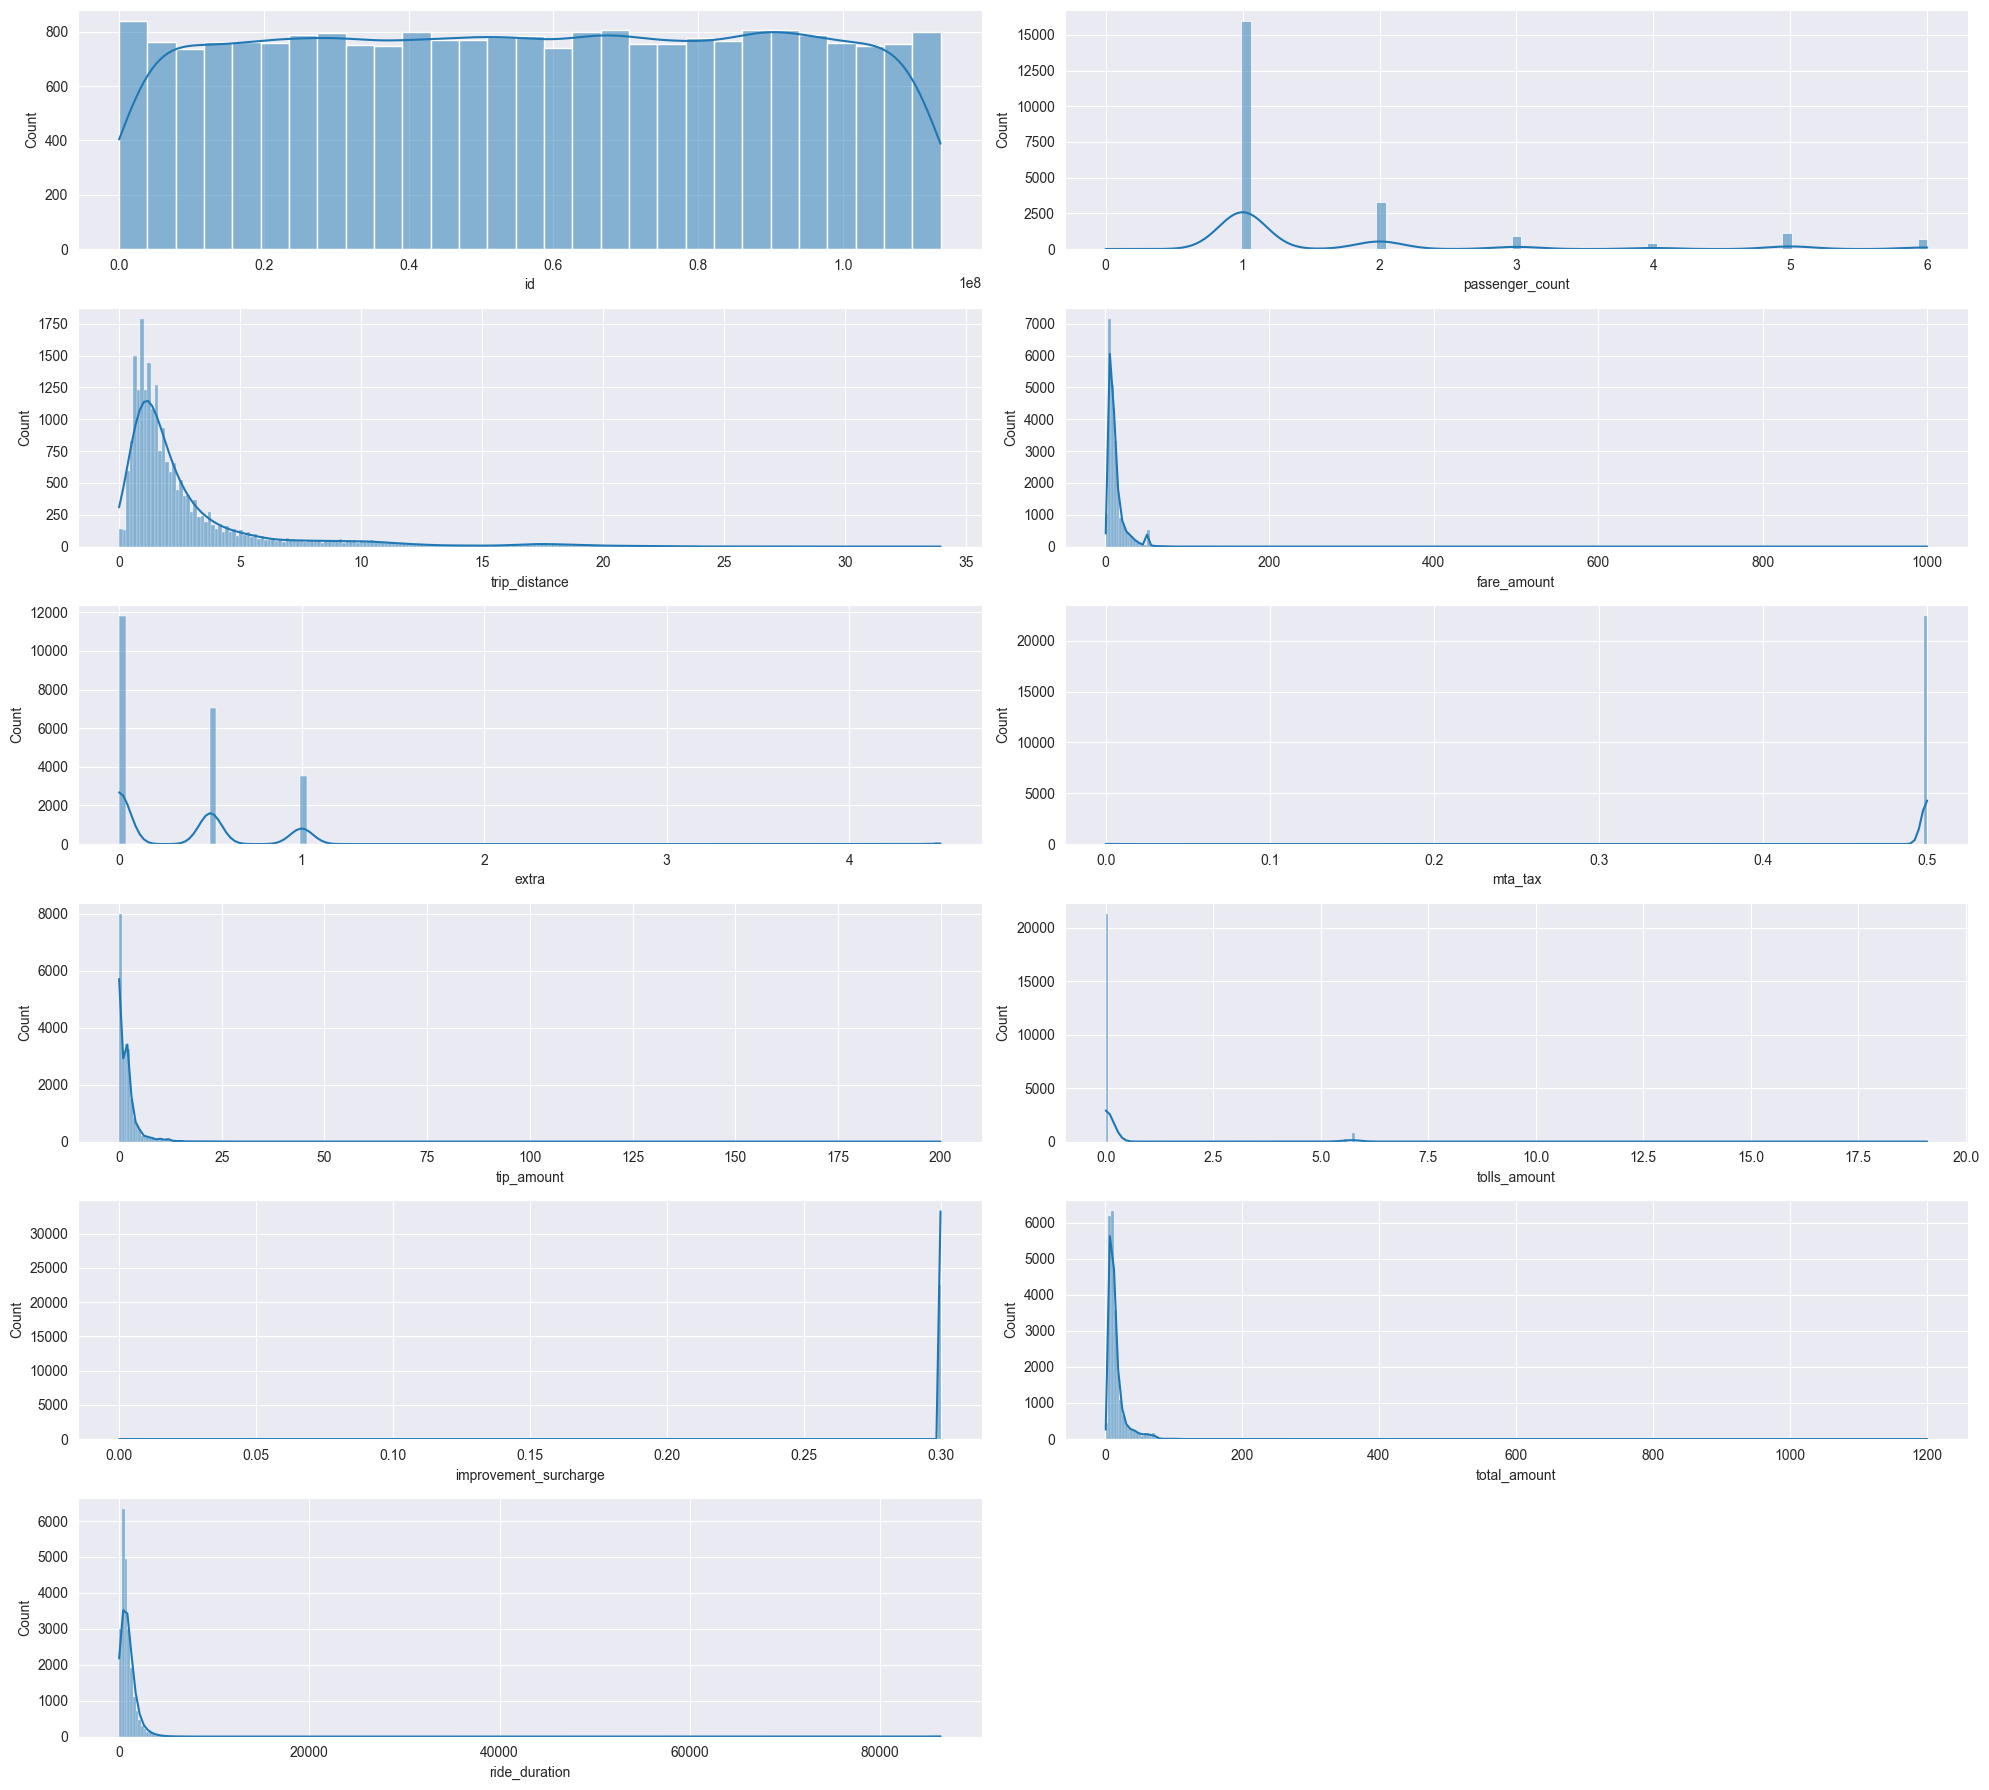

In [19]:
fig,axes = plt.subplots(nrows  = 6,ncols = 2,figsize = (20,18))
plt.subplots_adjust(hspace=0.4, wspace=0.25)
axes= axes.ravel()

for i in range(0,len(num_cols)):
    sns.histplot(df_tlc[num_cols[i]],ax = axes[i],kde = True)


for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



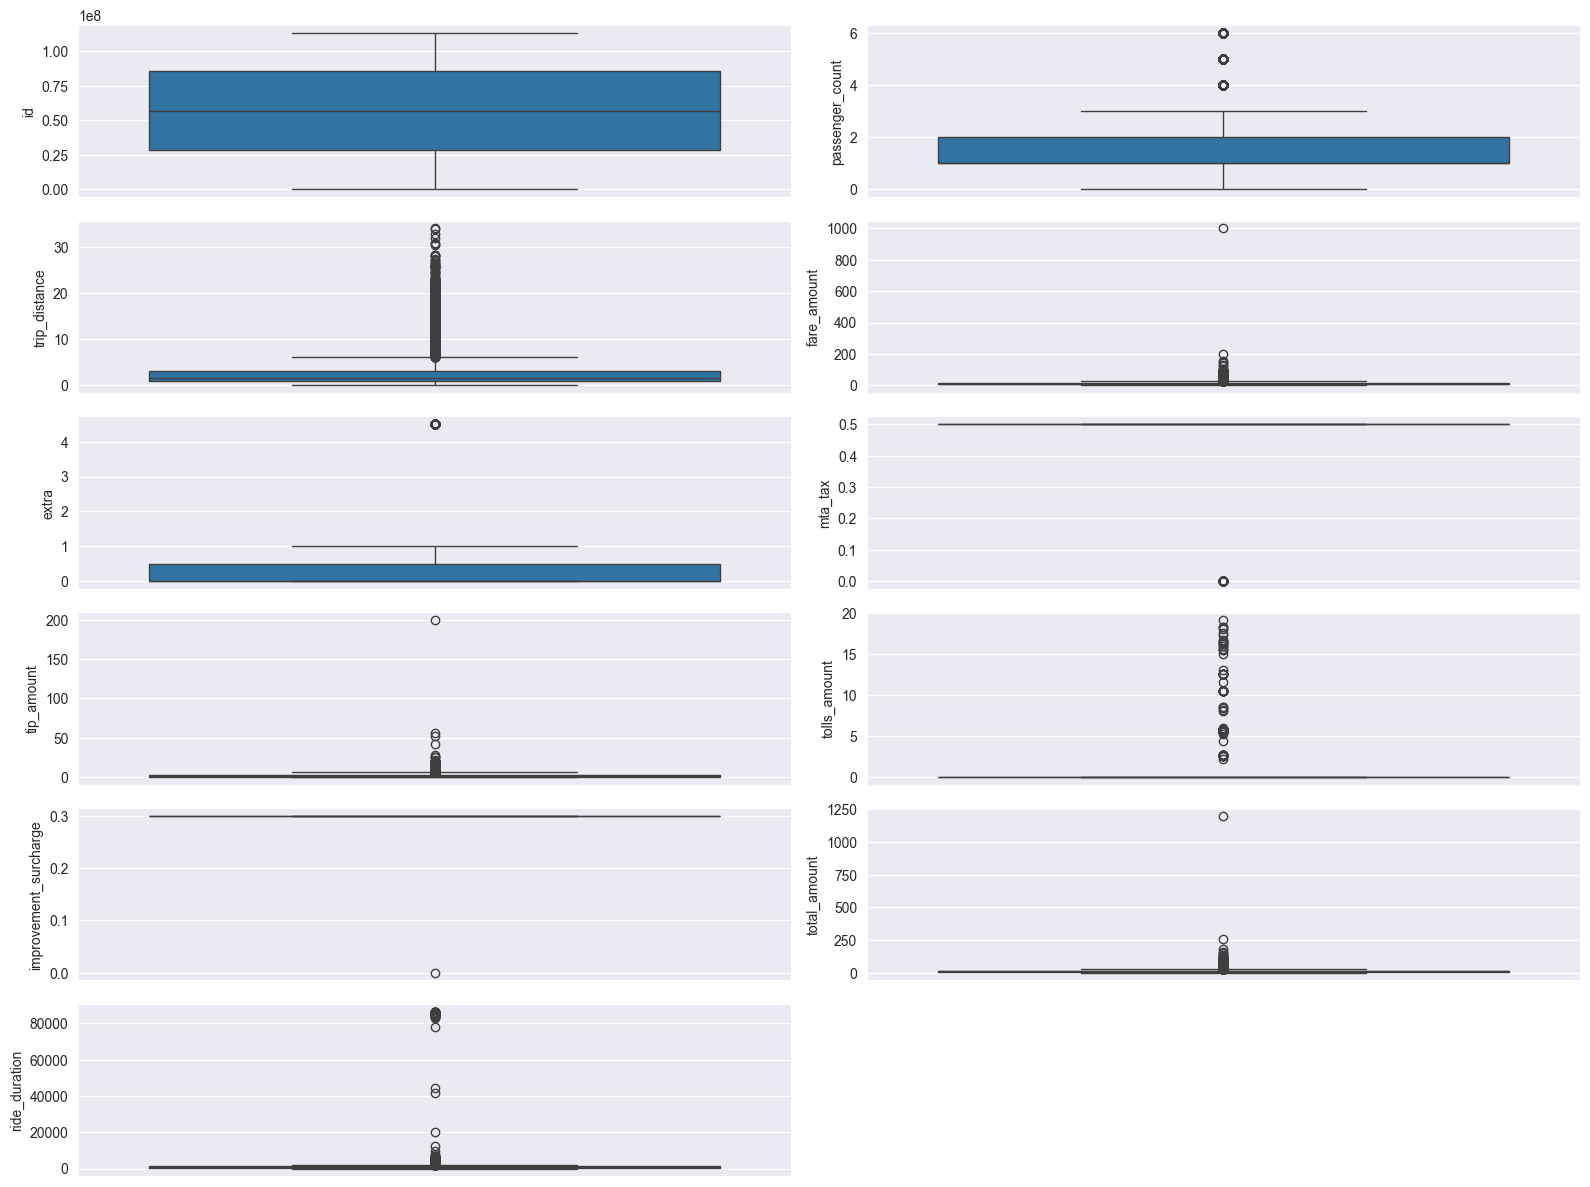

In [20]:
fig,axes = plt.subplots(nrows  = 6,ncols = 2,figsize = (16,12))
plt.subplots_adjust(hspace=0.4, wspace=0.25)
axes= axes.ravel()

for i in range(0,len(num_cols)):
    sns.boxplot(df_tlc[num_cols[i]],ax = axes[i])


for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Trip Distance
- Distribution is right-skewed with peak around 1–3 miles.
- Long-distance trips (up to ~34 miles) exist but are rare and appear valid.
- Presence of very small/zero distance is already addressed.


### Fare Amount
- Distribution is strongly right-skewed with a heavy tail.
- Majority of fares are concentrated at lower values, representing typical city rides.
- A secondary bump appears beyond ~$75, suggesting a distinct fare  (e.g., airport or long-distance rides).
- High-fare rides appear infrequent but potentially valid and should be analyzed separately.


### Ride Duration
- Distribution is strongly right-skewed with most rides under ~5,000 seconds.
- A long tail exists with durations extending up to ~80,000 seconds (~22 hours).
- Extremely long durations are likely anomalous and require validation against trip distance and fare.



### Tips

-  Distribution is strongly right-skewed with most tips under 3
-  Tail is upto 200




### Fare Components (MTA, Tolls, Extras)
- These fields represent post-ride fare components and are not available at prediction time.
- They should excluded from modeling to avoid data leakage.



In [21]:
df_tlc["trip_distance"].describe(percentiles =  [0.25,0.50,0.75,0.99,1])

count    22473.000000
mean         2.919153
std          3.644889
min          0.000000
25%          1.000000
50%          1.620000
75%          3.070000
99%         18.800000
100%        33.960000
max         33.960000
Name: trip_distance, dtype: float64

    ### To validate long-distance rides, we need to check whether they correspond to long durations and high fares.

In [22]:
long_rides = df_tlc["trip_distance"].quantile(0.99)

df_long = df_tlc.loc[df_tlc["trip_distance"] >= long_rides]
normal_df = df_tlc[df_tlc["trip_distance"] < long_rides]
df_long[["trip_distance" , "fare_amount","ride_duration"]].describe()

,trip_distance,fare_amount,ride_duration
count,226.000000,226.000000,226.000000
mean,21.390664,57.716858,3436.473451
std,2.882095,16.538134,5673.870200
min,18.800000,50.500000,1530.000000
25%,19.462500,52.000000,2206.500000
50%,20.500000,52.000000,2813.000000
75%,22.097500,55.000000,3581.250000
max,33.960000,200.010000,86200.000000


In [23]:
normal_df[["trip_distance" , "fare_amount","ride_duration"]].describe()

,trip_distance,fare_amount,ride_duration
count,22247.000000,22247.000000,22247.000000
mean,2.731507,12.482824,997.307952
std,3.136032,11.756593,3662.749016
min,0.000000,1.000000,0.000000
25%,1.000000,6.500000,401.000000
50%,1.600000,9.500000,667.000000
75%,3.000000,14.500000,1086.000000
max,18.790000,999.990000,86373.000000


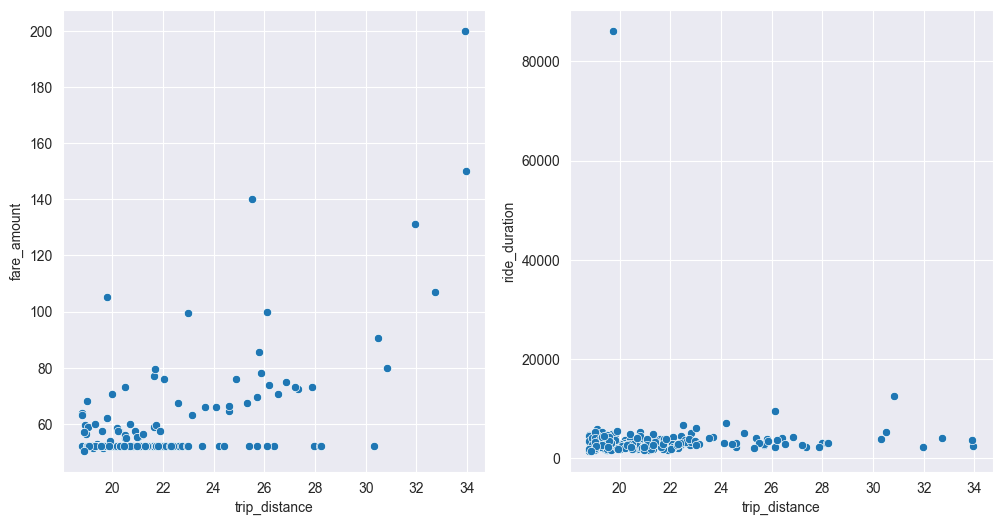

In [24]:
fig,axes = plt.subplots(ncols = 2,figsize = (12,6))
cols = ["fare_amount","ride_duration"]
axes = axes.ravel()

for i in range(2):
    sns.scatterplot(x ="trip_distance", y = cols[i], ax = axes[i], data = df_long )


Long-distance rides and normal rides show clearly different distributions across trip distance, duration, and fare.

Scatter plots confirm a positive relationship between trip distance and fare for long-distance rides.

Extreme values are observed in both long and normal rides, particularly in ride duration.

The ride that took 23 seconds for 22 miles has speed of 1.5 km/h thats impossible for a active ride, so remove this

200 fare is for longest ride si fine

In [25]:
df_tlc = df_tlc.loc[~(df_tlc["ride_duration"] == 86200)]

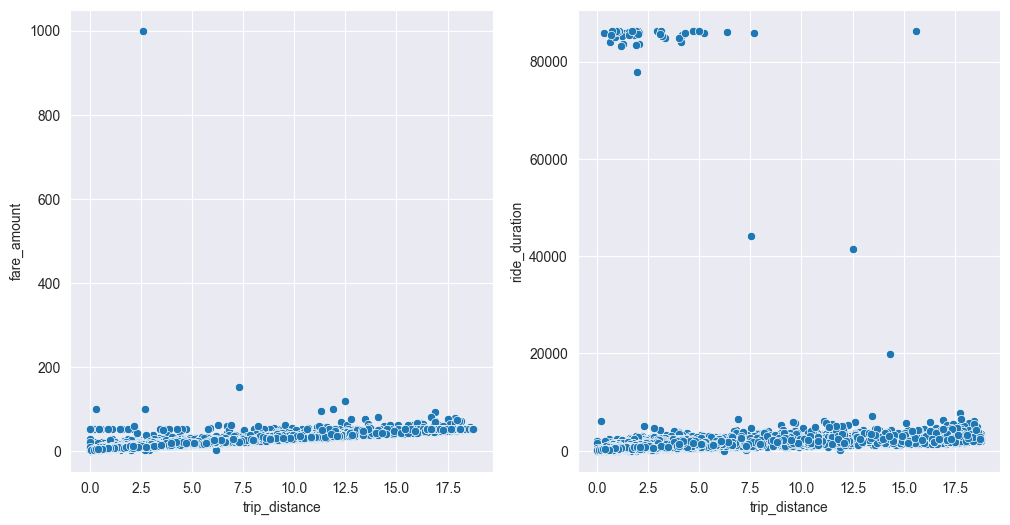

In [26]:
fig,axes = plt.subplots(ncols = 2,figsize = (12,6))
cols = ["fare_amount","ride_duration"]
axes = axes.ravel()

for i in range(2):
    sns.scatterplot(x ="trip_distance", y = cols[i], ax = axes[i], data = normal_df )

plt.show()

a single record shows an extremely high fare (~999) for a short trip (~3 miles), while the next highest fare is ~200.

This value is isolated, not representative of the underlying distribution, and likely results from data or pricing error.

To prevent disproportionate influence on model training, this record is removed.


In [27]:
df_tlc = df_tlc[~(df_tlc["fare_amount"] == 999.99)]

## Long Duration Anomalies

We observed a small number of records with extremely high trip durations (greater than 20,000 seconds) despite covering only a few miles.

- For **RateCodeID = 1 (standard metered rides)**, such records are considered **invalid**, as fare calculation depends on both time and distance. An unrealistically long duration for a short trip indicates timestamp corruption and breaks the fare–time relationship. These records were removed.

- For **RateCodeID ≠ 1 (flat or negotiated fares)**, fare calculation does not depend on the taximeter. In these cases, trip duration and distance are operational logs rather than pricing drivers and may be inconsistently recorded. Therefore, these records were retained and handled at the modeling stage rather than being removed during data cleaning.


In [28]:
df_tlc = df_tlc[~(
    (df_tlc["ride_duration"] >= 20000) )
]


In [32]:
df_tlc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22429 entries, 0 to 22698
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     22429 non-null  int64         
 1   VendorID               22429 non-null  object        
 2   tpep_pickup_datetime   22429 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  22429 non-null  datetime64[ns]
 4   passenger_count        22429 non-null  int64         
 5   trip_distance          22429 non-null  float64       
 6   RatecodeID             22429 non-null  object        
 7   store_and_fwd_flag     22429 non-null  object        
 8   PULocationID           22429 non-null  object        
 9   DOLocationID           22429 non-null  object        
 10  payment_type           22429 non-null  object        
 11  fare_amount            22429 non-null  float64       
 12  extra                  22429 non-null  float64       
 13  mta_ta

In [31]:
cat_cols = df_tlc.select_dtypes(include = ["object"]).columns.tolist() + ["passenger_count"]
cat_cols

['VendorID',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'passenger_count']

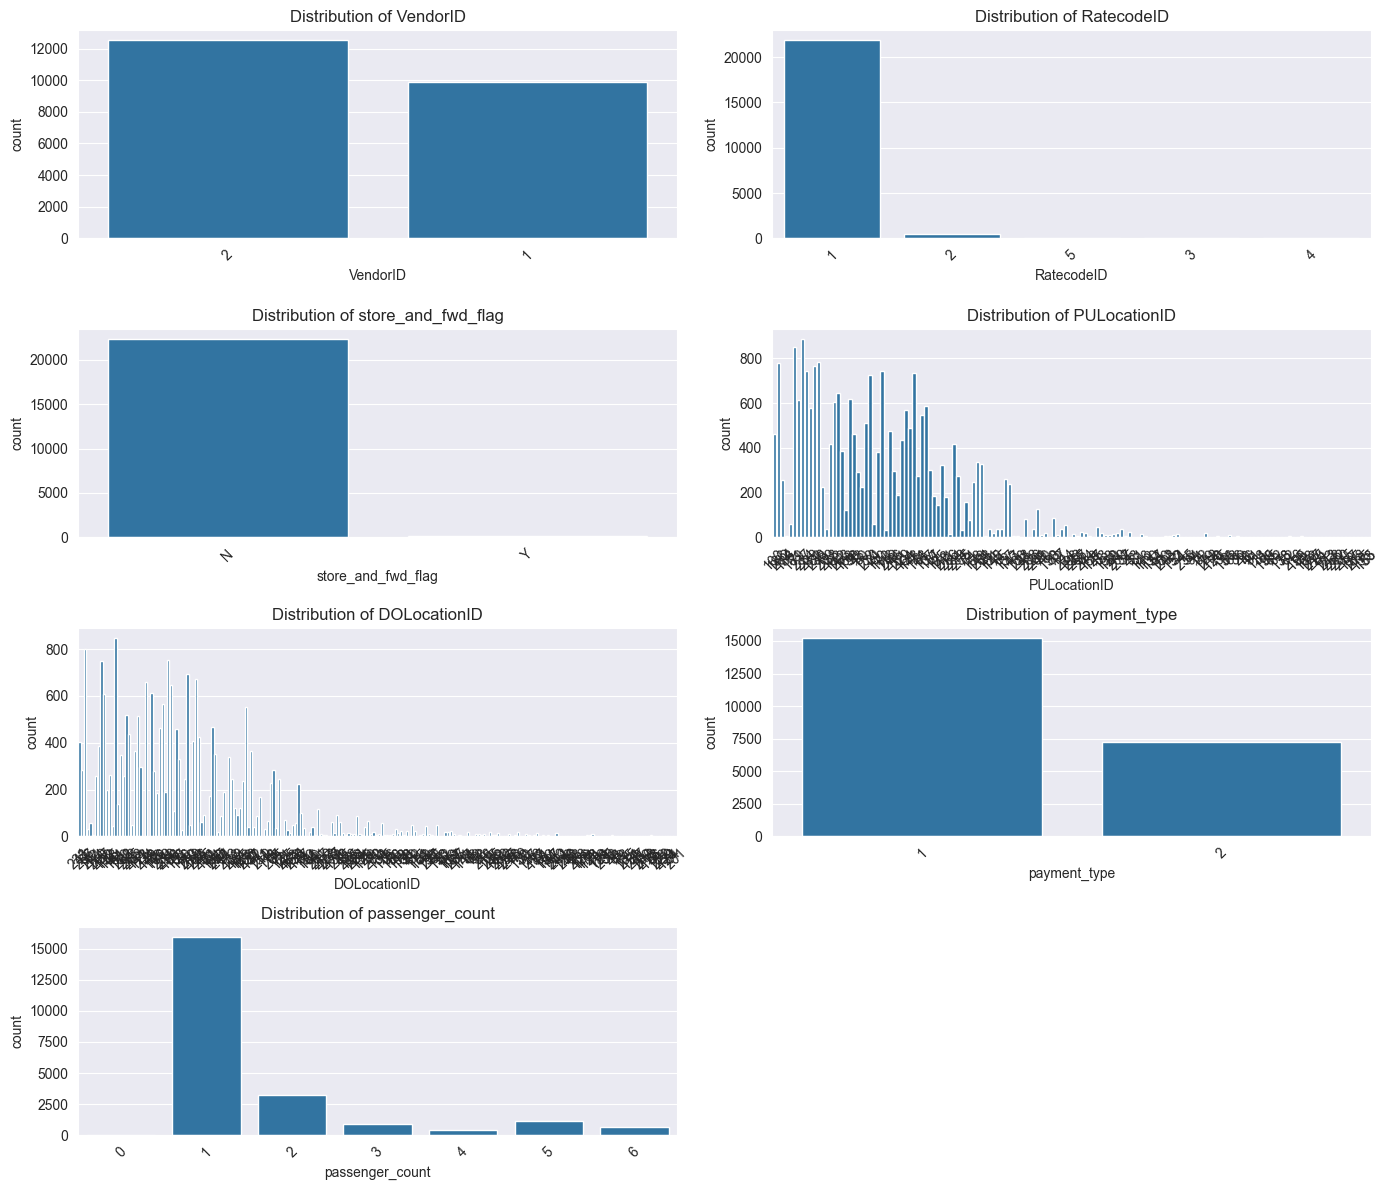

In [33]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.ravel()

for i, col in enumerate(cat_cols[:len(axes)]):
    sns.countplot(
        data=df_tlc,
        x=col,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=45)

# remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(
    r"C:\Users\Mohit Yadav\Downloads\categorical_univariate.png",
    dpi=300,
    bbox_inches="tight"
)



plt.show()


**Categorical Univariate Analysis — Findings**

**VendorID**
- Both vendors are well represented in the dataset, with **VendorID = 2 slightly more frequent than VendorID = 1**.
- The distribution is reasonably balanced, suggesting no major vendor dominance that would require corrective action.



**RateCodeID**
- **RateCodeID = 1 (standard metered rides)** overwhelmingly dominates the dataset.
- Other rate codes (2, 3, 4, 5) occur very infrequently.
- This indicates that most rides follow standard metered pricing, while non-metered or special fare rides represent rare but distinct scenarios.



**Store and Forward Flag**
- The vast majority of rides have `store_and_fwd_flag = 'N'`.
- Store-and-forward trips (`'Y'`) are extremely rare, indicating that GPS data transmission issues are uncommon.
- This feature is likely to have limited predictive power.



**Pickup Location ID (PULocationID)**
- Pickup locations are **highly skewed**, with a small subset of zones accounting for a large proportion of rides.
- Many zones appear infrequently, indicating strong spatial concentration of taxi demand.



**Dropoff Location ID (DOLocationID)**
- Similar to pickup locations, dropoff locations show a **long-tailed distribution**.
- A limited number of zones dominate dropoffs, while many zones are rarely used.
- This suggests spatial heterogeneity in trip destinations.



**Payment Type**
- **Credit card payments (payment_type = 1)** are significantly more common than cash payments (payment_type = 2).
- This aligns with modern taxi usage patterns and suggests payment type may carry behavioral signal for downstream tasks (e.g., tip prediction).



**Passenger Count**
- Most rides involve **a single passenger**, followed by two-passenger rides.
- Higher passenger counts (3–6) are relatively rare but present.
- The distribution reflects typical urban taxi usage and does not indicate data quality issues.


## Bivariate Analysis

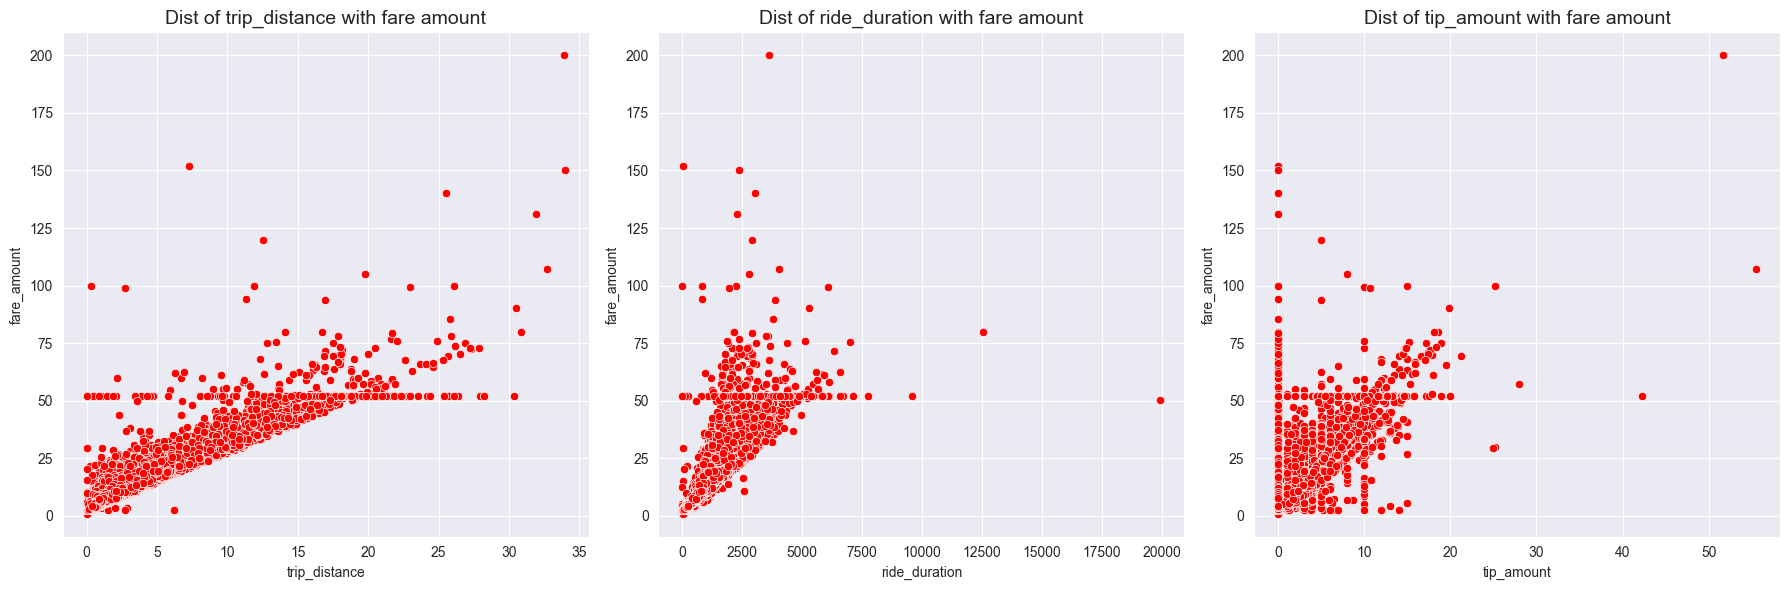

In [34]:
rel_cols = ["trip_distance", "ride_duration", "tip_amount"]
fig,axes = plt.subplots(ncols = 3, figsize=(18,6))


scatters = []
axes = axes.ravel()
for i in range(len(rel_cols)):
    sns.scatterplot(x = rel_cols[i], y = "fare_amount", ax = axes[i],data = df_tlc,color = "red")
    axes[i].set_title(f"Dist of {rel_cols[i]} with fare amount",fontsize = 14)



plt.tight_layout()
plt.show()


**Trip Distance vs Fare Amount**
- A strong increasing relationship is observed between trip distance and fare amount.
- The relationship is approximately linear for most trips, indicating distance as the primary driver of fare.
- A small number of high-fare, long-distance trips are present and appear valid (e.g., airport or special rides).

Trip distance is a critical predictive feature. Variance patterns suggest that transformations or robust models may improve performance, particularly for linear models.



**Ride Duration vs Fare Amount**
- A positive relationship exists between ride duration and fare amount, though weaker and noisier compared to trip distance.
- Longer durations with moderate fares indicate that time contributes to fare but is not the dominant factor.

**Implication:**
Ride duration provides secondary signal and should be retained as a supporting feature



**Tip Amount vs Fare Amount**
- A loose positive association is observed, where higher fares tend to have higher tip amounts.
- The relationship is highly noisy, with a large mass of zero or low tips.
- Tip amount is recorded after fare calculation and therefore occurs post-outcome.

**Implication:**
Although correlated, `tip_amount` is excluded from fare prediction modeling to avoid data leakage. This feature is suitable only for downstream tasks such as tip prediction.


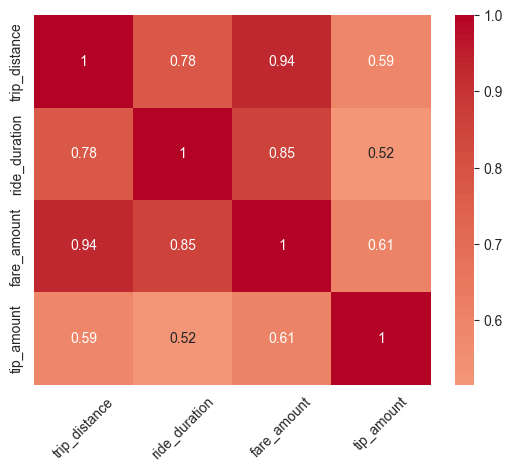

In [35]:
num_cols = ["trip_distance", "ride_duration", "fare_amount","tip_amount"]
sns.heatmap(df_tlc[num_cols].corr(),annot  = True,cmap="coolwarm",center=0)
plt.xticks(rotation=45)
plt.show()


### How price vary with passengers count ?

In [36]:
df_tlc.groupby("passenger_count").agg(mean_fare = ("fare_amount", "mean")).reset_index()

,passenger_count,mean_fare
0,0,12.187500
1,1,12.669838
2,2,13.719299
3,3,13.370626
4,4,13.353795
5,5,12.947276
6,6,12.928157


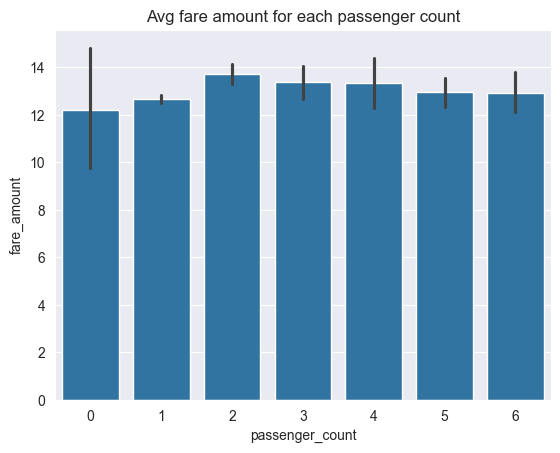

In [37]:
sns.barplot(x = "passenger_count", y = "fare_amount", data = df_tlc)
plt.title("Avg fare amount for each passenger count");

There is no visible relation between fare amount and passenger_count

Spikes on each bar is CI -  IT shows the uncertainity in the mean because it is a sample data

### How does different week days influence fare amount ?

In [38]:
df_tlc["weekday"] = df_tlc["tpep_pickup_datetime"].dt.day_name()

In [39]:
df_tlc.groupby("weekday").agg({"fare_amount": "mean" }).reset_index()

,weekday,fare_amount
0,Friday,12.976899
1,Monday,13.011986
2,Saturday,12.337695
3,Sunday,13.001969
4,Thursday,13.288504
5,Tuesday,12.757988
6,Wednesday,12.853515


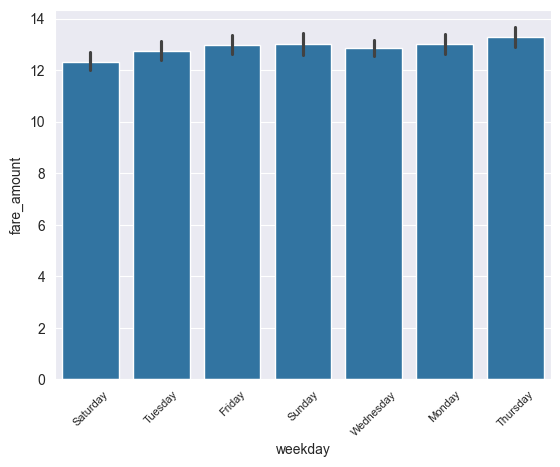

In [40]:
sns.barplot(x = "weekday", y = "fare_amount", data = df_tlc)
plt.xticks(rotation=45,fontsize = 8);

<Axes: xlabel='weekday', ylabel='fare_amount'>

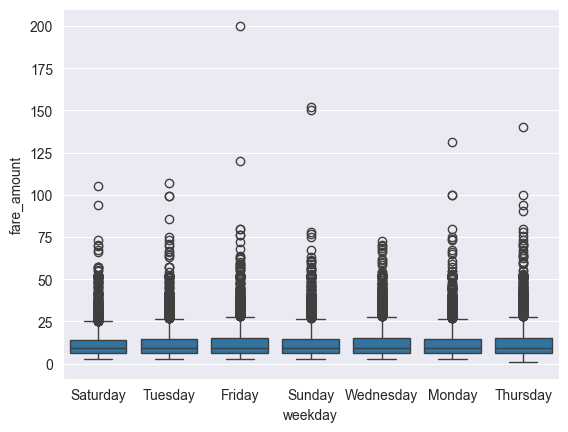

In [41]:
sns.boxplot(x = "weekday", y = "fare_amount", data = df_tlc)

This is expected, as the majority of rides follow standard metered pricing (RateCodeID = 1), where fares depend primarily on distance and elapsed time rather than day of the week.


In [42]:
import pandas as pd


hours = [0, 5, 9, 16, 20, 24]
labels = ["Late Night", "Morning Rush", "Mid Day","Evening Rush" , "Night"]

df_tlc["time_period"] = pd.cut(
    df_tlc["tpep_pickup_datetime"].dt.hour,
    bins=hours,
    labels=labels,
    include_lowest=True
)

In [43]:
df_tlc.groupby("time_period").agg({"fare_amount": "mean"}).reset_index()

C:\Users\Mohit Yadav\AppData\Local\Temp\ipykernel_2824\2290894145.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tlc.groupby("time_period").agg({"fare_amount": "mean"}).reset_index()


,time_period,fare_amount
0,Late Night,12.981514
1,Morning Rush,12.195480
2,Mid Day,13.258001
3,Evening Rush,12.668106
4,Night,13.013661


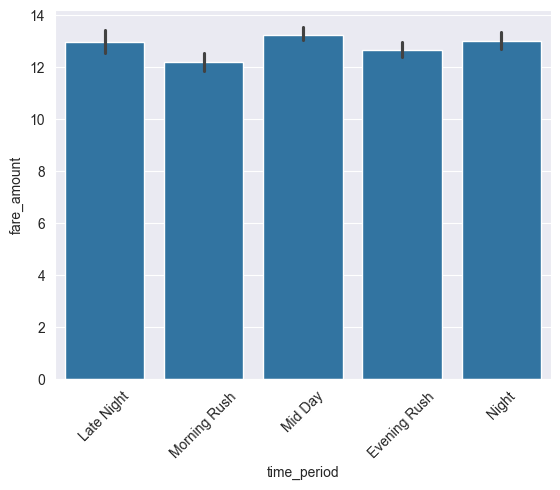

In [44]:
sns.barplot(x = "time_period", y = "fare_amount", data = df_tlc)
plt.xticks(rotation=45,fontsize = 10);

<Axes: xlabel='time_period', ylabel='fare_amount'>

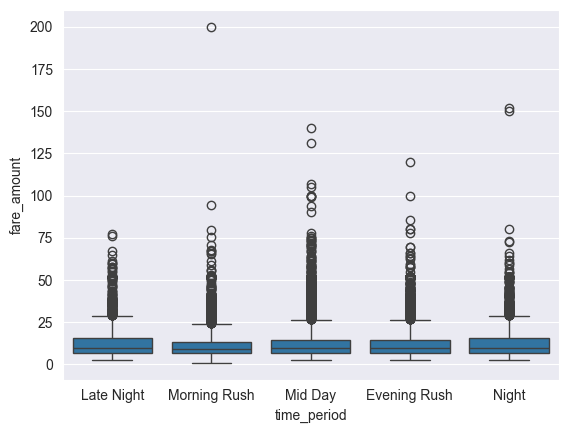

In [45]:
sns.boxplot(x = "time_period", y = "fare_amount", data = df_tlc)

Mean fare shows minimal variation across different times of day.
This is expected, as the majority of rides follow standard metered pricing (RateCodeID = 1), where fares depend primarily on distance and elapsed time rather than time-of-day categories.

Any congestion-related effects during peak hours are likely absorbed into ride duration and averaged out in aggregate fare statistics, resulting in limited observable differences in mean fare.


### How fare vary with RateCode?

In [46]:
df_tlc.groupby("RatecodeID")["fare_amount"].mean()

RatecodeID
1    11.817616
2    52.000000
3    65.457143
4    73.875000
5    73.173824
Name: fare_amount, dtype: float64

<Axes: xlabel='RatecodeID', ylabel='fare_amount'>

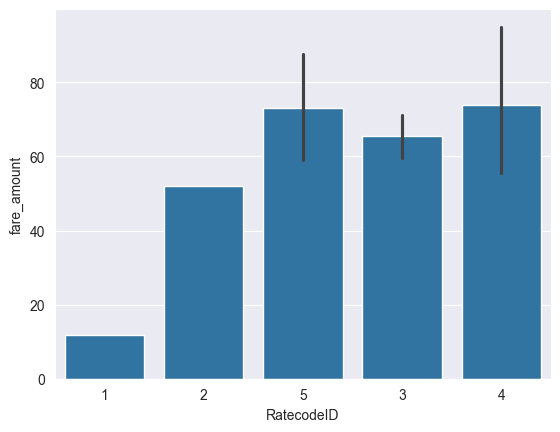

In [47]:
sns.barplot(x = "RatecodeID", y = "fare_amount", data = df_tlc)



<Axes: xlabel='RatecodeID', ylabel='fare_amount'>

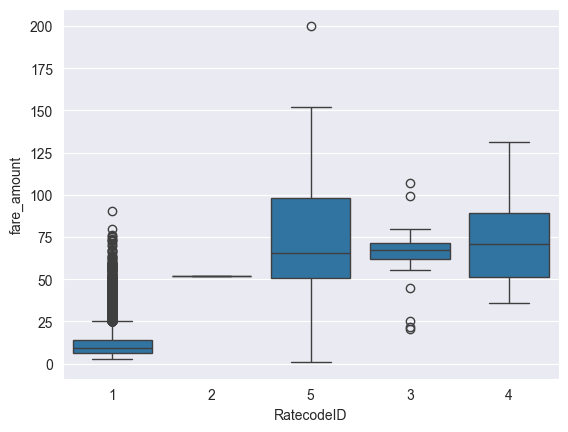

In [48]:
sns.boxplot(x = "RatecodeID", y = "fare_amount", data = df_tlc)


Mean fare differs substantially across rate codes, with standard metered rides (RateCodeID = 1) having significantly lower fares compared to other rate codes.

The dominance of RateCodeID = 1 in the dataset explains why aggregated analyses across time-of-day, weekday, and passenger count show minimal variation in mean fare. Secondary effects are diluted when combined with the overwhelmingly larger volume of standard metered rides.

For RateCodeID = 2, fare values is fixed (52), so we will apply rule here. There is no need for model to predict it.


These effects are better examined conditionally or through multivariate analysis. To capture this regime difference explicitly, a binary feature distinguishing standard metered rides from other rate codes can be introduced during feature engineering.


### Does payment type affect fare_amount for Ratecode 1 ?

<Axes: xlabel='payment_type', ylabel='fare_amount'>

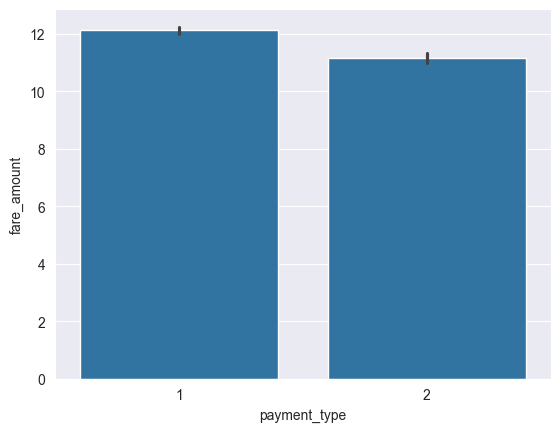

In [49]:
sns.barplot(x = "payment_type", y = "fare_amount", data = df_tlc[df_tlc["RatecodeID"]=="1"])

In [50]:
from scipy.stats import ttest_ind

gpa = df_tlc[(df_tlc["payment_type"] == "1") & (df_tlc["RatecodeID"] == "1")]["fare_amount"]
gpb = df_tlc[(df_tlc["payment_type"] == "2") & (df_tlc["RatecodeID"] == "1")]["fare_amount"]

# Corrected: compare gpa to gpb
ttest_ind(gpa, gpb, nan_policy='omit',equal_var = False)


TtestResult(statistic=np.float64(8.073407587113682), pvalue=np.float64(7.377768199724131e-16), df=np.float64(14315.19850560282))

**we are rejecting null hypothesis here, There is high statistic significant proof that mean fare amount for different payment type is not by chance**

### Does fare amount depend on VendorId ?

<Axes: xlabel='VendorID', ylabel='fare_amount'>

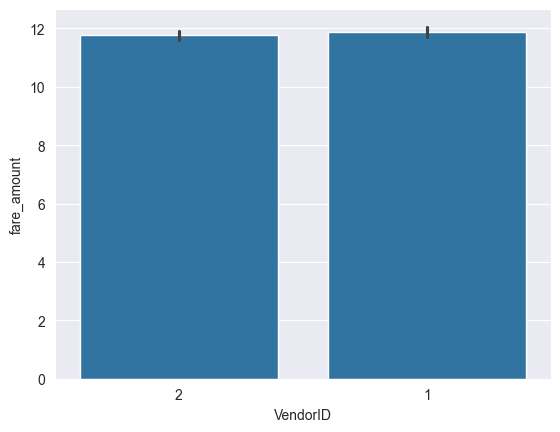

In [51]:
sns.barplot(x = "VendorID", y = "fare_amount", data = df_tlc[df_tlc["RatecodeID"]=="1"])

In [52]:
from scipy.stats import ttest_ind

gpa = df_tlc[(df_tlc["VendorID"] == "1") & (df_tlc["RatecodeID"] == "1")]["fare_amount"]
gpb = df_tlc[(df_tlc["VendorID"] == "2") & (df_tlc["RatecodeID"] == "1")]["fare_amount"]

# Corrected: compare gpa to gpb
ttest_ind(gpa, gpb, nan_policy='omit',equal_var = False)


TtestResult(statistic=np.float64(0.9577046173546377), pvalue=np.float64(0.3382229058386645), df=np.float64(20712.871228736356))

**p value is 33.8 % way more than 0.5%. We can not reject null hypothesis and we got expected result. VendorID does not influence fare amount**

In [53]:
df_tlc["VendorID"].value_counts()

VendorID
2    12532
1     9897
Name: count, dtype: int64

### Multivariate Analysis

<Axes: xlabel='trip_distance', ylabel='fare_amount'>

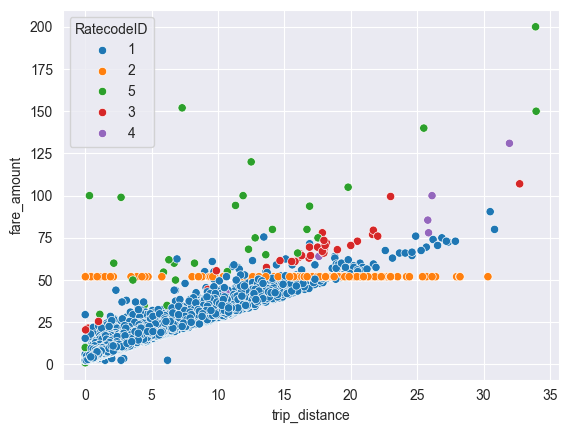

In [54]:
sns.scatterplot(x = "trip_distance", y = "fare_amount", data = df_tlc,hue = "RatecodeID")

The distance–fare relationship differs by pricing regime; flat fares are deterministic, metered rides are highly linear with distance, and negotiated fares introduce high variance.

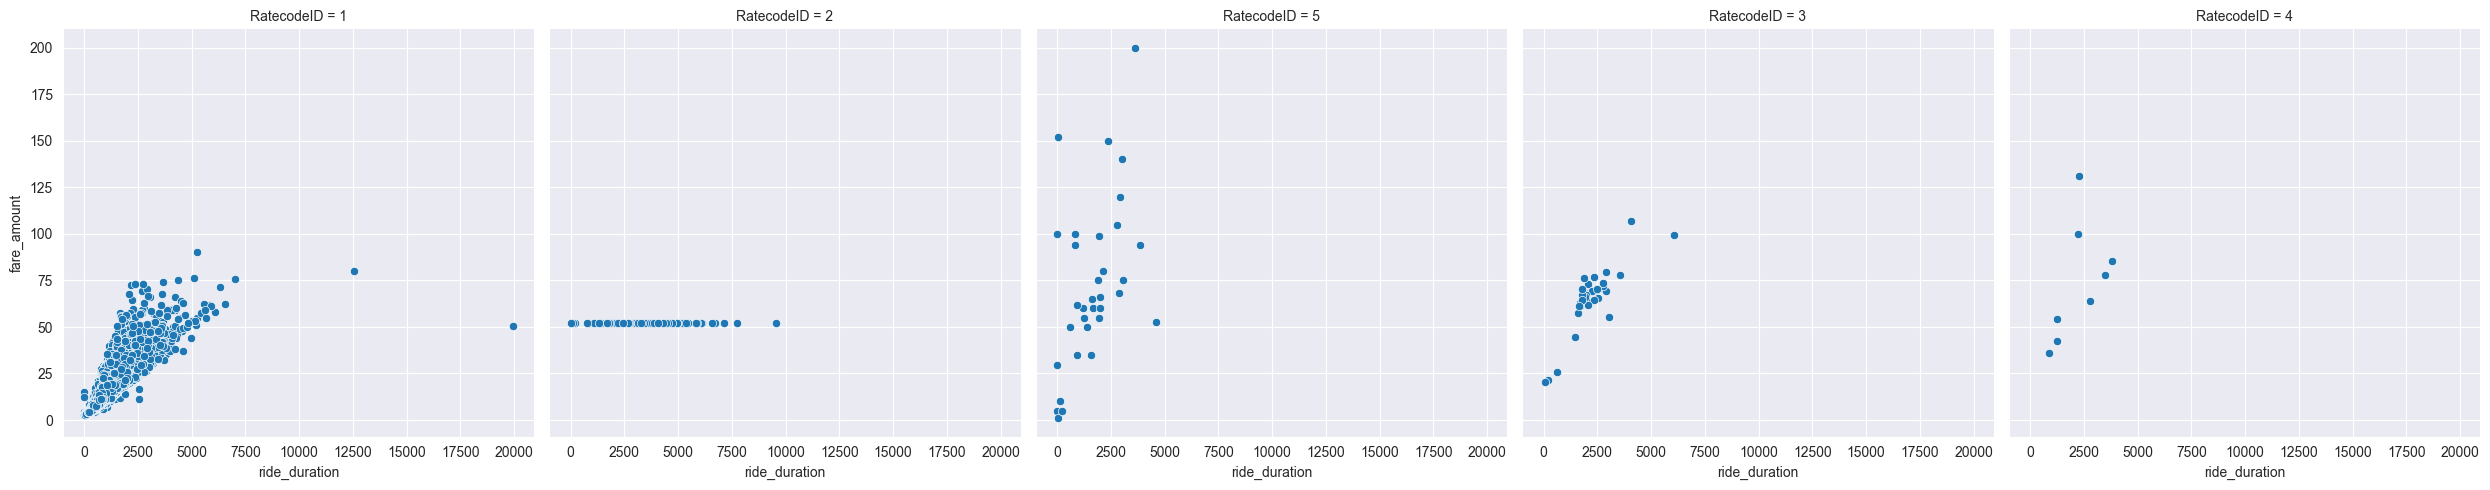

In [55]:
sns.relplot(
    x="ride_duration",
    y="fare_amount",
    col="RatecodeID",
    data=df_tlc,
    kind="scatter"
)


It conveys the same information as prev plot becuase duration and distance are correlated

### How avg fares are affected by different time of day for all Ratecodes?

In [119]:
pivot = (
    df_tlc
    .pivot_table(
        values="fare_amount",
        columns="time_period",
        index="RatecodeID",
        aggfunc="mean"
    )
)

pivot


C:\Users\Mohit Yadav\AppData\Local\Temp\ipykernel_2824\3028426045.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


time_period,Late Night,Morning Rush,Mid Day,Evening Rush,Night
RatecodeID,,,,,
1,12.149525,11.181859,12.051869,11.48316,12.210200
3,67.875000,59.500000,67.138889,66.00000,64.500000
4,NaN,36.000000,84.375000,81.75000,54.000000
5,39.257143,90.302500,87.590909,53.94000,88.385714


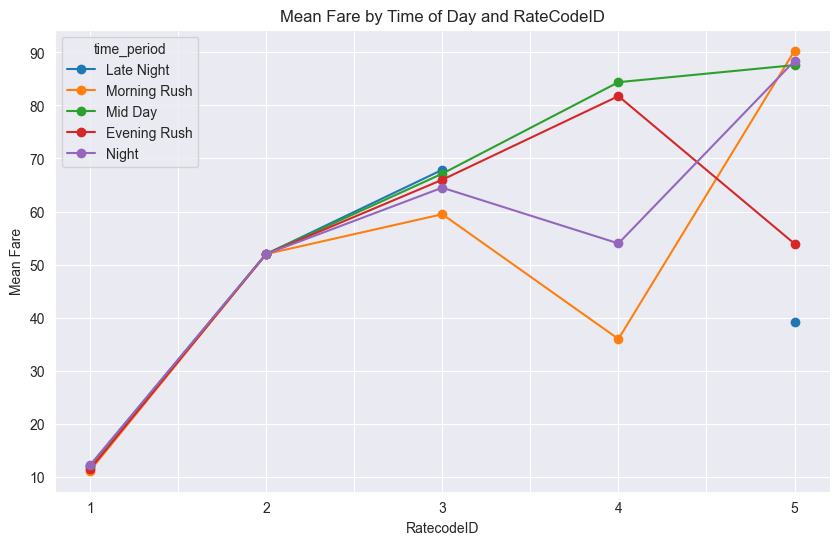

In [57]:
pivot.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.ylabel("Mean Fare")
plt.title("Mean Fare by Time of Day and RateCodeID")
plt.grid(True)
plt.show()


In [58]:
df_tlc["RatecodeID"].value_counts()

RatecodeID
1    21866
2      486
3       35
5       34
4        8
Name: count, dtype: int64

Cross-tabulation of mean fare by time-of-day and RateCodeID shows that standard metered rides (RateCodeID = 1) and flat-fare rides (RateCodeID = 2) exhibit minimal variation across time periods. For other rate codes, observed differences are inconsistent and likely driven by smaller sample sizes and heterogeneous pricing rules rather than systematic time effects.


## How does mean fare change wrt to Ratecode and weekday ?

In [59]:

df_tlc.pivot_table(
        values="fare_amount",
        columns="weekday",
        index="RatecodeID",
        aggfunc="mean"
    )




weekday,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
RatecodeID,,,,,,,
1,11.895264,11.687277,11.270487,11.753235,12.251982,11.756717,12.070778
2,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
3,70.200000,70.250000,56.750000,56.937500,63.187500,79.333333,67.750000
4,64.000000,115.500000,NaN,78.000000,NaN,85.500000,44.166667
5,95.335000,65.950000,58.840000,74.360000,68.993750,87.000000,64.125000


Mean fare by weekday shows minimal variation for standard metered rides (RateCodeID = 1), indicating that weekday effects are weak once pricing regime is controlled. Larger fluctuations observed for other rate codes are inconsistent and likely driven by small sample sizes rather than systematic weekday patterns. Weekday is retained as a low-impact feature and evaluated during modeling.


In [60]:
df_tlc["is_weekend"] = df_tlc["weekday"].map( lambda a : 1 if a in ["Saturday","Sunday"] else 0)

df_tlc.head()

,id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,ride_duration,weekday,time_period,is_weekend
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.0,0.5,2.76,0.0,0.3,16.56,844.0,Saturday,Morning Rush,1
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,0.0,0.5,4.00,0.0,0.3,20.80,1590.0,Tuesday,Mid Day,0
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,0.0,0.5,1.45,0.0,0.3,8.75,432.0,Friday,Morning Rush,0
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,0.0,0.5,6.39,0.0,0.3,27.69,1815.0,Sunday,Mid Day,1
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,0.5,0.5,0.00,0.0,0.3,17.80,1003.0,Saturday,Night,1


In [61]:
df_tlc.groupby("is_weekend")["fare_amount"].mean()

is_weekend
0    12.979562
1    12.649411
Name: fare_amount, dtype: float64

In [62]:
gpa = df_tlc[df_tlc["is_weekend"] == 1]["fare_amount"]

gpb = df_tlc.loc[df_tlc["is_weekend"] == 0, "fare_amount"]

ttest_ind(gpa,gpb, equal_var = False,alternative = "less")

TtestResult(statistic=np.float64(-2.066040647472752), pvalue=np.float64(0.019423452701168294), df=np.float64(11540.809627836179))

weekend rides are cheaper than weekday rides

### Check is there any significant diff among the avg fare amout of different time of the day

In [63]:
from scipy.stats import f_oneway

df_rate1 = df_tlc[df_tlc['RatecodeID'] == "1"]

late_night = df_rate1[df_rate1['time_period'] == 'Late Night']['fare_amount']
morning_rush = df_rate1[df_rate1['time_period'] == 'Morning Rush']['fare_amount']
mid_day = df_rate1[df_rate1['time_period'] == 'Mid Day']['fare_amount']
evening_rush = df_rate1[df_rate1['time_period'] == 'Evening Rush']['fare_amount']
night = df_rate1[df_rate1['time_period'] == 'Night']['fare_amount']

# One-way ANOVA
f_stat, p_val = f_oneway(late_night, morning_rush, mid_day, evening_rush, night)

print(f"F-Statistic: {f_stat}, P-value: {p_val:.10f}")

F-Statistic: 11.360401183142733, P-value: 0.0000000033


There is a significant diff between the fare amount of different different time of the day

In [64]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# pairwise_tukeyhsd(Dependent Variable, Grouping Variable, Alpha)
tukey = pairwise_tukeyhsd(endog=df_rate1['fare_amount'],
                          groups=df_rate1['time_period'],
                          alpha=0.05)

print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
Evening Rush   Late Night   0.6664 0.0117  0.0999  1.2328   True
Evening Rush      Mid Day   0.5687 0.0014  0.1607  0.9768   True
Evening Rush Morning Rush  -0.3013 0.4722 -0.8027  0.2001  False
Evening Rush        Night    0.727 0.0007  0.2267  1.2274   True
  Late Night      Mid Day  -0.0977 0.9879 -0.6359  0.4405  False
  Late Night Morning Rush  -0.9677 0.0002 -1.5797 -0.3557   True
  Late Night        Night   0.0607 0.9988 -0.5505  0.6718  False
     Mid Day Morning Rush    -0.87    0.0 -1.3392 -0.4008   True
     Mid Day        Night   0.1583 0.8882 -0.3097  0.6264  False
Morning Rush        Night   1.0283    0.0   0.477  1.5797   True
----------------------------------------------------------------


## Feature Engineering

### Deterministic FE ( Does learn from data so no need to split)

In [65]:
flat_rides_df = df_tlc[df_tlc["RatecodeID"] =="2"]

df_tlc = df_tlc[~(df_tlc["RatecodeID"] =="2")]

Separated flat fare rides and rest

In [116]:
df_tlc.loc[:,"is_metered"] = (df_tlc["RatecodeID"]=="1").astype(int)

show if the ride is standard/ metered or not

In [115]:
df_tlc.loc[:,"is_weekend"]  = df_tlc["weekday"].map(lambda a : 1 if a in ["Saturday","Sunday"] else 0)

show of the ride is on weekend or not

In [68]:
df_tlc.columns

Index(['id', 'VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'ride_duration', 'weekday', 'time_period', 'is_weekend',
       'is_metered'],
      dtype='object')

In [69]:
import holidays

holiday = holidays.US(state = "NY")

In [117]:
df_tlc.loc[:,"is_holiday"] = df_tlc["tpep_pickup_datetime"].dt.date.map(lambda a : 1 if a in holiday else 0 )

show if the ride is on US holidays

In [118]:
df_tlc.loc[:,"speed"] = df_tlc['trip_distance']/(df_tlc['ride_duration']/3600)


Show avg speed during the ride

In [72]:
df_tlc.columns

Index(['id', 'VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'ride_duration', 'weekday', 'time_period', 'is_weekend',
       'is_metered', 'is_holiday', 'speed'],
      dtype='object')

## Model Building

In [73]:
from sklearn.model_selection import train_test_split
req_columns = ['passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag','ride_duration','weekday', 'time_period', 'is_weekend','is_metered', 'is_holiday']

df_model = df_tlc[req_columns]

In [74]:
df_model["store_and_fwd_flag"].unique()

array(['N', 'Y'], dtype=object)

In [75]:

Xtrain,Xtest,ytrain,ytest  = train_test_split(df_model, df_tlc["fare_amount"], test_size = 0.2, random_state = 42)

In [76]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import r2_score

In [98]:
ct = ColumnTransformer(transformers = [
    ("outlier_treating" , RobustScaler(),["trip_distance","ride_duration"]),
    ("stds" , StandardScaler(),["passenger_count"]),
    ("onehot",OneHotEncoder(sparse_output=False,handle_unknown = "ignore",drop = "first"),["RatecodeID","store_and_fwd_flag","weekday","time_period","is_weekend","is_metered","is_holiday"] )],
    remainder = "passthrough")

In [99]:
estimators = [("lr", LinearRegression()),("dt",DecisionTreeRegressor())]

stack_model = StackingRegressor(estimators = estimators,final_estimator=Ridge(),cv = 5)

In [100]:
pipe = make_pipeline(ct,stack_model)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('stackingregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('outlier_treating', ...), ('stds', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If 

In [101]:
pipe.named_steps

{'columntransformer': ColumnTransformer(remainder='passthrough',
                   transformers=[('outlier_treating', RobustScaler(),
                                  ['trip_distance', 'ride_duration']),
                                 ('stds', StandardScaler(), ['passenger_count']),
                                 ('onehot',
                                  OneHotEncoder(drop='first',
                                                handle_unknown='ignore',
                                                sparse_output=False),
                                  ['RatecodeID', 'store_and_fwd_flag', 'weekday',
                                   'time_period', 'is_weekend', 'is_metered',
                                   'is_holiday'])]),
 'stackingregressor': StackingRegressor(cv=5,
                   estimators=[('lr', LinearRegression()),
                               ('dt', DecisionTreeRegressor())],
                   final_estimator=Ridge())}

In [102]:
params = {
    'stackingregressor__passthrough': [True, False],

    'stackingregressor__dt__min_samples_split': [5, 10, 20, 40],
    'stackingregressor__dt__max_depth': [5, 7, 9, 11],

    'stackingregressor__dt__criterion': ["squared_error", "friedman_mse"],
    'stackingregressor__dt__splitter': ["best", "random"],
    'stackingregressor__final_estimator__alpha': [0.1, 0.5, 1, 2, 3, 4]
}


Gd = GridSearchCV(estimator=pipe, param_grid=params, cv=5, scoring='r2',n_jobs=-1)


In [103]:
Gd.fit(Xtrain,ytrain)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...or=Ridge()))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'stackingregressor__dt__criterion': ['squared_error', 'friedman_mse'], 'stackingregressor__dt__max_depth': [5, 7, ...], 'stackingregressor__dt__min_samples_split': [5, 10, ...], 'stackingregressor__dt__splitter': ['best', 'random'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbos

In [112]:
Xtrain.columns

Index(['passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'ride_duration', 'weekday', 'time_period', 'is_weekend', 'is_metered',
       'is_holiday'],
      dtype='object')

In [104]:
Gd.best_score_

np.float64(0.9765075368900605)

In [105]:

Gd.best_params_

{'stackingregressor__dt__criterion': 'squared_error',
 'stackingregressor__dt__max_depth': 11,
 'stackingregressor__dt__min_samples_split': 20,
 'stackingregressor__dt__splitter': 'best',
 'stackingregressor__final_estimator__alpha': 0.5,
 'stackingregressor__passthrough': True}

In [106]:
model = Gd.best_estimator_
pred = model.predict(Xtest)

In [107]:
r2_score(ytest,pred)

0.9526107323556169

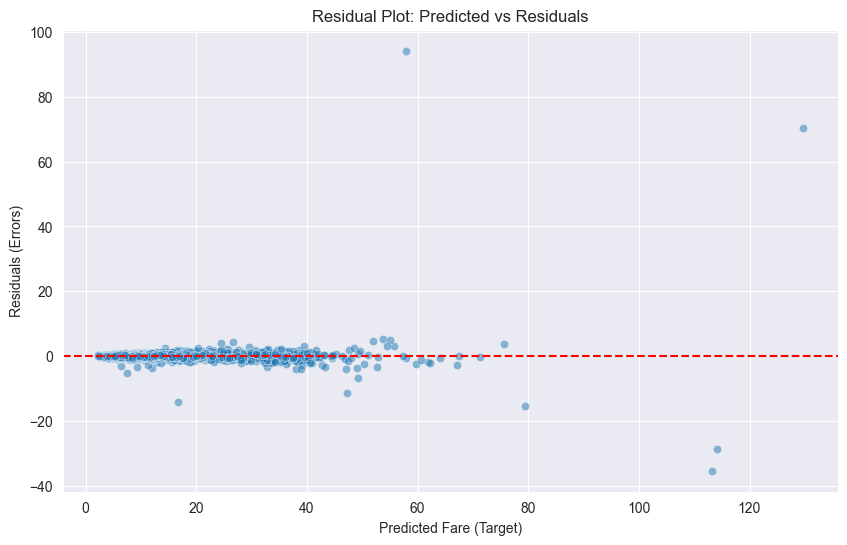

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns




residuals = ytest - pred

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--') # Zero error line
plt.title('Residual Plot: Predicted vs Residuals')
plt.xlabel('Predicted Fare (Target)')
plt.ylabel('Residuals (Errors)')
plt.show()

In [109]:
import pickle

In [110]:
with open("model.pkl", "wb") as f:
    pickle.dump(model,f)

In [111]:

with open("pipe.pkl", "wb") as f:
    pickle.dump(pipe,f)